In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../data/hab_labels_lis.csv")
df['time'] = pd.to_datetime(df['time'], utc=True)
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['season'] = df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

print(f"Total records: {len(df):,}")
print(f"Date range: {df['time'].min()} to {df['time'].max()}")
print(f"Unique stations: {df['station_name'].nunique()}")
print(f"Bloom rate: {df['bloom'].mean()*100:.1f}%")

Total records: 1,358,852
Date range: 1993-11-02 05:00:00+00:00 to 2025-08-28 04:00:00+00:00
Unique stations: 50
Bloom rate: 19.4%


In [2]:
# Bloom rate by station
station_stats = df.groupby('station_name').agg(
    total=('bloom', 'count'),
    blooms=('bloom', 'sum'),
    mean_chl=('Chlorophyll', 'mean'),
    lat=('latitude', 'first'),
    lon=('longitude', 'first')
).reset_index()

station_stats['bloom_rate'] = station_stats['blooms'] / station_stats['total'] * 100
station_stats = station_stats.sort_values('bloom_rate', ascending=False)

print(station_stats[['station_name', 'total', 'bloom_rate', 'mean_chl', 'lat', 'lon']].head(15).to_string())

   station_name  total  bloom_rate   mean_chl        lat        lon
32           A2     54   46.296296  18.764815  40.800835 -73.787330
3            04  12224   40.027814  10.370492  40.937830 -73.519330
6            07  12038   39.333776  10.189635  40.950333 -73.425330
1            02  15744   37.836636  10.114451  40.934666 -73.600670
33           A4  81276   35.486490  11.385802  40.872500 -73.734170
34           B3  43277   35.286642  11.055334  40.918335 -73.642830
0            01  15570   34.810533   9.886046  40.963333 -73.623665
4            05  13699   32.104533   9.608217  41.009335 -73.513664
13           15  34377   29.342293   9.492542  40.931330 -73.221170
5            06  17713   28.843222   8.516593  40.961166 -73.476670
10           12   9383   28.636897   8.877195  41.108665 -73.253000
9            10  15907   27.956246   8.655191  40.951668 -73.332500
35           C1  46718   27.278565   8.991318  40.955833 -73.580330
14           16   8128   26.648622   9.001241  4

In [3]:
# Sort by lowest bloom rate
print(station_stats[['station_name', 'total', 'bloom_rate', 'mean_chl', 'lat', 'lon']].tail(15).to_string())

   station_name  total  bloom_rate  mean_chl        lat        lon
17           20  16765   16.301819  6.209064  40.994000 -73.042336
23           27  12348   15.338516  5.722380  41.158670 -72.849500
42           H4  50075   14.797803  5.740163  41.101665 -72.934000
16           19  18412   14.582881  5.473245  41.055332 -73.080830
19           22  18871   14.344762  5.267338  41.082333 -73.022835
38           E1  84588   14.147397  5.488309  41.019333 -73.291336
40           F3  87489   12.680451  5.273964  41.017834 -73.144500
24           28  11720   12.474403  4.530982  41.078167 -72.833500
44           I2  53826   11.672798  5.302490  41.137500 -72.655000
45           J2  34641   10.799342  5.439606  41.182000 -72.457664
43           H6  84227   10.503758  4.741427  41.026000 -72.913500
46           J4   1090    8.165138  6.413496  41.097500 -72.450000
47           K2  63492    5.907831  4.058809  41.234333 -72.265830
48           M3  66175    4.692104  3.908718  41.237167 -72.05

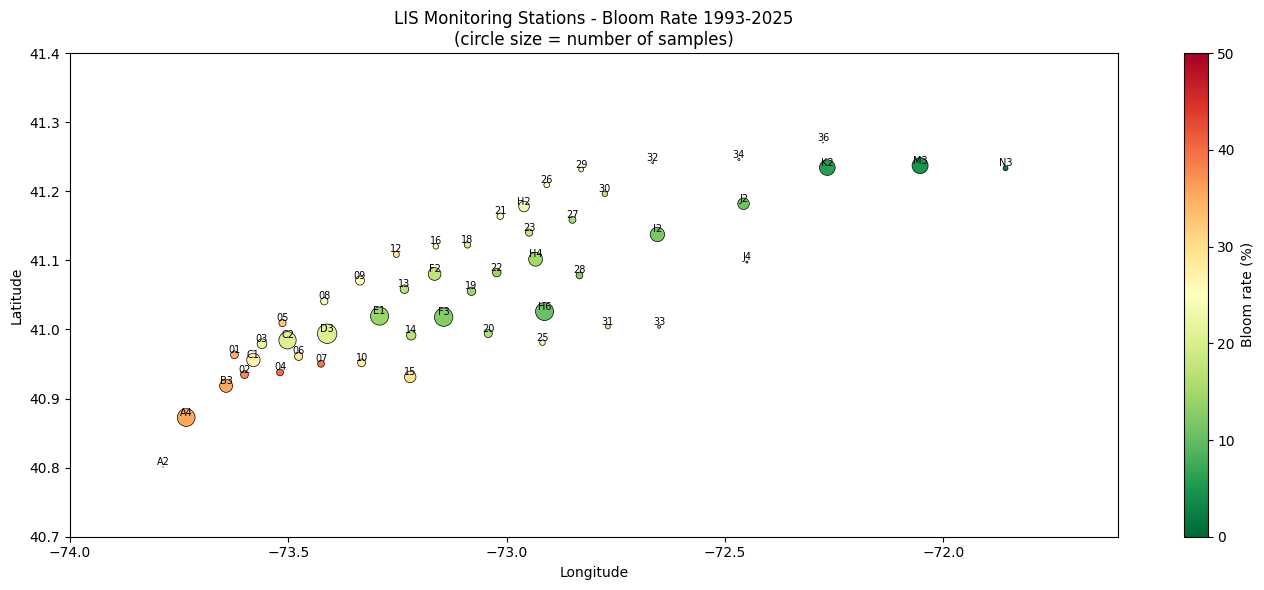

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

scatter = ax.scatter(
    station_stats['lon'],
    station_stats['lat'],
    c=station_stats['bloom_rate'],
    s=station_stats['total']/500,
    cmap='RdYlGn_r',
    vmin=0, vmax=50,
    edgecolors='black',
    linewidth=0.5
)

plt.colorbar(scatter, ax=ax, label='Bloom rate (%)')

for _, row in station_stats.iterrows():
    ax.annotate(row['station_name'], 
                (row['lon'], row['lat']),
                fontsize=7, ha='center', va='bottom')

ax.set_title('LIS Monitoring Stations - Bloom Rate 1993-2025\n(circle size = number of samples)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim(-74.0, -71.6)
ax.set_ylim(40.7, 41.4)
plt.tight_layout()
plt.savefig('../figures/station_bloom_rates.png', dpi=150)
plt.show()

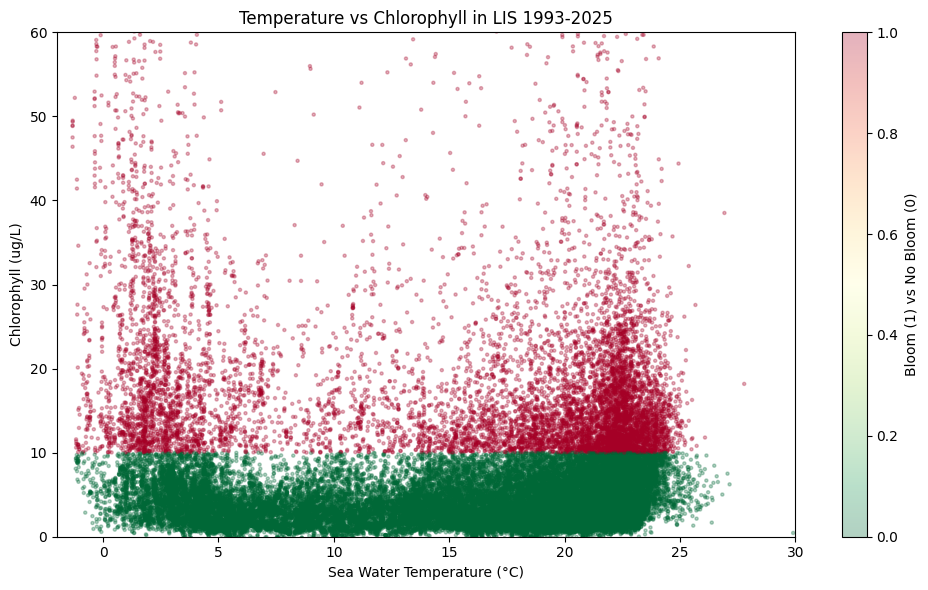

In [5]:
# Sample 50k points so it doesn't take forever to plot
sample = df[df['sea_water_temperature'].notna() & df['Chlorophyll'].notna()].sample(50000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    sample['sea_water_temperature'],
    sample['Chlorophyll'],
    c=sample['bloom'],
    cmap='RdYlGn_r',
    alpha=0.3,
    s=5
)

ax.set_xlim(-2, 30)
ax.set_ylim(0, 60)
ax.set_xlabel('Sea Water Temperature (°C)')
ax.set_ylabel('Chlorophyll (ug/L)')
ax.set_title('Temperature vs Chlorophyll in LIS 1993-2025')
plt.colorbar(scatter, ax=ax, label='Bloom (1) vs No Bloom (0)')
plt.tight_layout()
plt.savefig('../figures/temp_vs_chl.png', dpi=150)
plt.show()

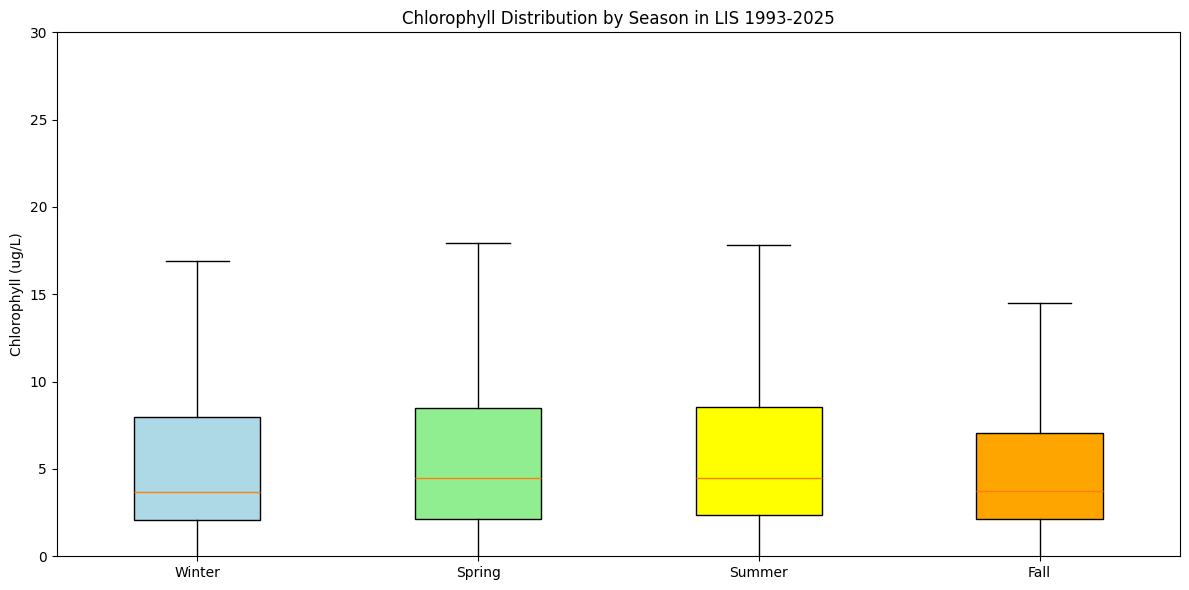

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_data = [df[df['season'] == s]['Chlorophyll'].dropna() for s in seasons]

bp = ax.boxplot(season_data, tick_labels=seasons, patch_artist=True,
                showfliers=False)

colors = ['lightblue', 'lightgreen', 'yellow', 'orange']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_title('Chlorophyll Distribution by Season in LIS 1993-2025')
ax.set_ylabel('Chlorophyll (ug/L)')
ax.set_ylim(0, 30)
plt.tight_layout()
plt.savefig('../figures/seasonal_chl_distribution.png', dpi=150)
plt.show()

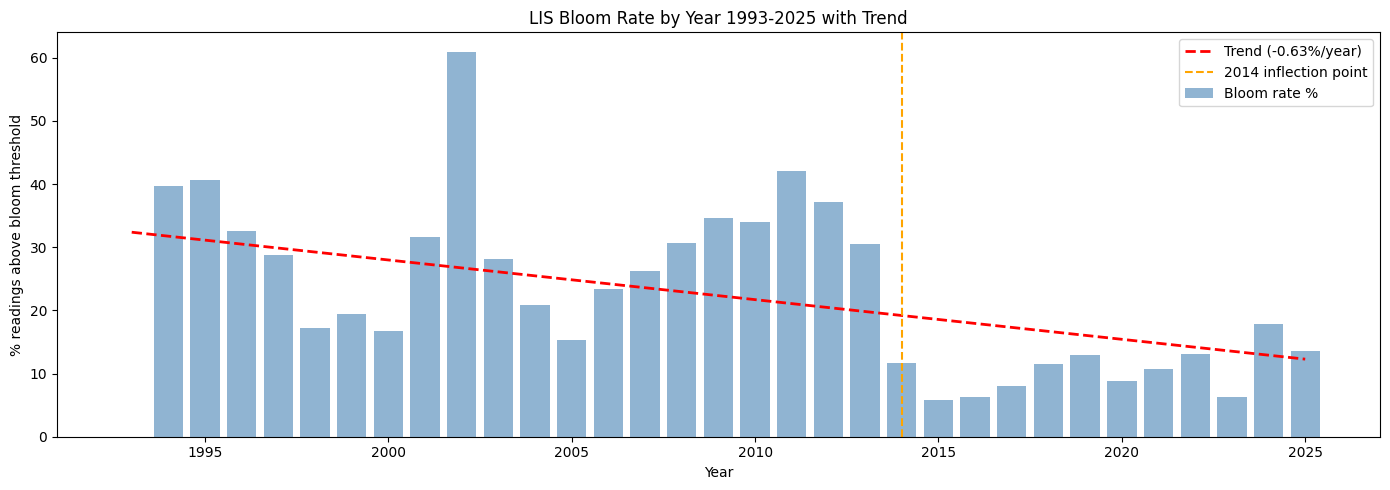

Overall trend: -0.63% per year


In [8]:
yearly = df.groupby('year').agg(
    bloom_rate=('bloom', 'mean'),
    mean_chl=('Chlorophyll', 'mean')
).reset_index()

# Fit trend lines
z1 = np.polyfit(yearly['year'], yearly['bloom_rate']*100, 1)
p1 = np.poly1d(z1)

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(yearly['year'], yearly['bloom_rate']*100, color='steelblue', alpha=0.6, label='Bloom rate %')
ax.plot(yearly['year'], p1(yearly['year']), 'r--', linewidth=2, label=f'Trend ({z1[0]:+.2f}%/year)')
ax.axvline(x=2014, color='orange', linestyle='--', linewidth=1.5, label='2014 inflection point')

ax.set_title('LIS Bloom Rate by Year 1993-2025 with Trend')
ax.set_ylabel('% readings above bloom threshold')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/bloom_trend.png', dpi=150)
plt.show()

print(f"Overall trend: {z1[0]:+.2f}% per year")